# Sentiment Analysis

### Importing modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, ElasticNet
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import DecisionBoundaryDisplay

from tqdm import tqdm

import torch
import spacy
from nltk.corpus import stopwords
import string
from torch.optim import AdamW
from transformers import pipeline
import torch.nn.functional as F
from datasets import Dataset

from collections import Counter
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification

### Loading dataframes

In [2]:
df1 = pd.read_csv('./IMDB-Dataset.csv')

In [3]:
label_mapping = {'negative': 0, 'positive': 1}
df1['label'] = df1['sentiment'].map(label_mapping)

df1['label'] = df1['label'].astype(int)

df1

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1
...,...,...,...
49995,I thought this movie did a down right good job...,positive,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,0
49997,I am a Catholic taught in parochial elementary...,negative,0
49998,I'm going to have to disagree with the previou...,negative,0


### Splitting into train sets and test sets

In [4]:
X = df1['review']
y = df1['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Converting `review` into numerical values using tf-idf

In [5]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_tfidf = vectorizer.fit_transform(X)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Logistic Regression

In [6]:
model1 = LogisticRegression(max_iter=1000)

model1.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
y_pred1 = model1.predict(X_test_tfidf)

In [8]:
print('Accuracy: ', accuracy_score(y_test, y_pred1))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred1))

Accuracy:  0.8889333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      7411
           1       0.88      0.90      0.89      7589

    accuracy                           0.89     15000
   macro avg       0.89      0.89      0.89     15000
weighted avg       0.89      0.89      0.89     15000



## L2 (Ridge) Regularization

In [9]:
model2 = LogisticRegression(solver='saga', penalty='l2', C=0.01)

model2.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [10]:
y_pred2 = model2.predict(X_test_tfidf)

In [11]:
print('Accuracy: ', accuracy_score(y_test, y_pred2))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred2))

Accuracy:  0.8294666666666667

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.80      0.82      7411
           1       0.81      0.86      0.84      7589

    accuracy                           0.83     15000
   macro avg       0.83      0.83      0.83     15000
weighted avg       0.83      0.83      0.83     15000



## L1 (Lasso) Regularization

In [12]:
model3 = LogisticRegression(solver='saga', penalty='l1', C=0.01)

model3.fit(X_train_tfidf, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [13]:
y_pred3 = model3.predict(X_test_tfidf)

In [14]:
print('Accuracy: ', accuracy_score(y_test, y_pred3))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred3))

Accuracy:  0.6556666666666666

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.41      0.54      7411
           1       0.61      0.90      0.72      7589

    accuracy                           0.66     15000
   macro avg       0.70      0.65      0.63     15000
weighted avg       0.70      0.66      0.63     15000



## GridSearchCV

In [15]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(solver='saga', max_iter=1000))
])

param_grid = {
    'tfidf__max_features': [3000, 5000, 10000],
    'tfidf__ngram_range': [(1,1),(1,2)],
    'tfidf__min_df': [1, 5],
    'tfidf__max_df': [0.8, 0.9],
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2'],
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

Since GridSearchCV runs too slow, in case we put a large dataframe, we shall slice series `X_train`, `y_train`.

In [16]:
X_small = X_train[:10000]
y_small = y_train[:10000]

In [17]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 96 candidates, totalling 288 fits


,estimator,Pipeline(step...ver='saga'))])
,param_grid,"{'clf__C': [0.01, 0.1, ...], 'clf__penalty': ['l2'], 'tfidf__max_df': [0.8, 0.9], 'tfidf__max_features': [3000, 5000, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [18]:
y_pred4 = grid.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred4))

Accuracy:  0.8923333333333333


## RandomizedSearchCV

#### RandomizedSearchCV is much faster than GridSearchCV.

In [19]:
random_search = RandomizedSearchCV(pipeline, param_distributions=param_grid, n_iter=10, cv=3, n_jobs=-1, verbose=2)

In [20]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step...ver='saga'))])
,param_distributions,"{'clf__C': [0.01, 0.1, ...], 'clf__penalty': ['l2'], 'tfidf__max_df': [0.8, 0.9], 'tfidf__max_features': [3000, 5000, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [21]:
y_pred5 = random_search.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred5))

Accuracy:  0.8923333333333333


## Elastic Net

In [22]:
log_reg = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    max_iter=5000,
    # multi_class="multinomial"
)

param_grid = {
    "C": [0.1, 1.0, 10.0],
    "l1_ratio": [0.2, 0.5, 0.8]
}

In [23]:
grid_search = GridSearchCV(
    log_reg, param_grid, cv=3, scoring="accuracy"
)

In [24]:
grid_search.fit(X_train_tfidf, y_train)

,estimator,LogisticRegre...solver='saga')
,param_grid,"{'C': [0.1, 1.0, ...], 'l1_ratio': [0.2, 0.5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'elasticnet'


In [25]:
best_model = grid_search.best_estimator_

y_pred7 = best_model.predict(X_test_tfidf)

In [26]:
print("Best parameters:", grid_search.best_params_)
print("Accuracy: ", accuracy_score(y_test, y_pred7))

Best parameters: {'C': 1.0, 'l1_ratio': 0.2}
Accuracy:  0.8894


## Support Vector Machine

In [27]:
svm = SVC(kernel="linear", C=1)

In [28]:
svm.fit(X_tfidf, y)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [29]:
y_pred8 = svm.predict(X_test_tfidf)

In [30]:
print("Accuracy: ", accuracy_score(y_test, y_pred8))

Accuracy:  0.6400666666666667


## K-Nearest Neighbor (KNN)

In [38]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_tfidf, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
y_pred9 = knn.predict(X_test_tfidf)
print(f'Test Accuracy (k=5): {accuracy_score(y_test, y_pred9):.2f}')

Test Accuracy (k=5): 0.72


In [40]:
k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_tfidf, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

In [41]:
best_k = k_range[np.argmax(cv_scores)]
print(f'Best k from cross-validation: {best_k}')

Best k from cross-validation: 19


In [42]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_tfidf, y_train)

,n_neighbors,19
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [43]:
y_pred9 = best_knn.predict(X_test_tfidf)

In [44]:
print("Accuracy: ", accuracy_score(y_test, y_pred9))

Accuracy:  0.7446666666666667


## Testing our models

In [26]:
def predict_sentiment(text, model=None):
    if model == None:
        model = model1
    text_tfidf = vectorizer.transform([text])
    prediction = model.predict(text_tfidf)
    return prediction[0]

def predict_text(text, model=None):
    if model == None:
        model = grid
    return model.predict([text])[0]

In [27]:
print('\"This was a good film.\": ', predict_sentiment('This was a good film.'))
print('\"This was a horrible film.\": ', predict_sentiment('This was a horrible film.'))
print('\"The film was so good, that I had to turn it off.\": ', predict_sentiment('The film was so good, that I had to turn it off.'))
print('\"The film was good, although there were some horrible scenes.\": ', predict_sentiment('The film was good, although there were some horrible scenes.'))
print('\"A bad ending, but I loved the film.\": ', predict_sentiment('A bad ending, but I loved the film.'))
print('\"I was fascinated when he saved them, but I didn\'t like the film.\": ', predict_sentiment('I was fascinated when he saved them, but I didn\'t like the film.'))
print('\"There were disgusting scenes, but that\'s ok, the film was just fine.\": ', predict_sentiment('There were disgusting scenes, but that\'s ok, the film was just fine.'))

"This was a good film.":  positive
"This was a horrible film.":  negative
"The film was so good, that I had to turn it off.":  positive
"The film was good, although there were some horrible scenes.":  negative
"A bad ending, but I loved the film.":  positive
"I was fascinated when he saved them, but I didn't like the film.":  negative
"There were disgusting scenes, but that's ok, the film was just fine.":  negative


In [28]:
print('\"This was a good film.\": ', predict_sentiment('This was a good film.', model2))
print('\"This was a horrible film.\": ', predict_sentiment('This was a horrible film.', model2))
print('\"The film was so good, that I had to turn it off.\": ', predict_sentiment('The film was so good, that I had to turn it off.', model2))
print('\"The film was good, although there were some horrible scenes.\": ', predict_sentiment('The film was good, although there were some horrible scenes.', model2))
print('\"A bad ending, but I loved the film.\": ', predict_sentiment('A bad ending, but I loved the film.', model2))
print('\"I was fascinated when he saved them, but I didn\'t like the film.\": ', predict_sentiment('I was fascinated when he saved them, but I didn\'t like the film.', model2))
print('\"There were disgusting scenes, but that\'s ok, the film was just fine.\": ', predict_sentiment('There were disgusting scenes, but that\'s ok, the film was just fine.', model2))

"This was a good film.":  positive
"This was a horrible film.":  negative
"The film was so good, that I had to turn it off.":  positive
"The film was good, although there were some horrible scenes.":  negative
"A bad ending, but I loved the film.":  negative
"I was fascinated when he saved them, but I didn't like the film.":  negative
"There were disgusting scenes, but that's ok, the film was just fine.":  negative


In [29]:
print('\"This was a good film.\": ', predict_sentiment('This was a good film.', model3))
print('\"This was a horrible film.\": ', predict_sentiment('This was a horrible film.', model3))
print('\"The film was so good, that I had to turn it off.\": ', predict_sentiment('The film was so good, that I had to turn it off.', model3))
print('\"The film was good, although there were some horrible scenes.\": ', predict_sentiment('The film was good, although there were some horrible scenes.', model3))
print('\"A bad ending, but I loved the film.\": ', predict_sentiment('A bad ending, but I loved the film.', model3))
print('\"I was fascinated when he saved them, but I didn\'t like the film.\": ', predict_sentiment('I was fascinated when he saved them, but I didn\'t like the film.', model3))
print('\"There were disgusting scenes, but that\'s ok, the film was just fine.\": ', predict_sentiment('There were disgusting scenes, but that\'s ok, the film was just fine.'))

"This was a good film.":  positive
"This was a horrible film.":  positive
"The film was so good, that I had to turn it off.":  positive
"The film was good, although there were some horrible scenes.":  positive
"A bad ending, but I loved the film.":  negative
"I was fascinated when he saved them, but I didn't like the film.":  positive
"There were disgusting scenes, but that's ok, the film was just fine.":  negative


In [30]:
print('\"This was a good film.\": ', predict_text('This was a good film.'))
print('\"This was a horrible film.\": ', predict_text('This was a horrible film.'))
print('\"The film was so good, that I had to turn it off.\": ', predict_text('The film was so good, that I had to turn it off.'))
print('\"The film was good, although there were some horrible scenes.\": ', predict_text('The film was good, although there were some horrible scenes.'))
print('\"A bad ending, but I loved the film.\": ', predict_text('A bad ending, but I loved the film.'))
print('\"I was fascinated when he saved them, but I didn\'t like the film.\": ', predict_text('I was fascinated when he saved them, but I didn\'t like the film.'))
print('\"There were disgusting scenes, but that\'s ok, the film was just fine.\": ', predict_text('There were disgusting scenes, but that\'s ok, the film was just fine.'))

"This was a good film.":  positive
"This was a horrible film.":  negative
"The film was so good, that I had to turn it off.":  positive
"The film was good, although there were some horrible scenes.":  negative
"A bad ending, but I loved the film.":  positive
"I was fascinated when he saved them, but I didn't like the film.":  negative
"There were disgusting scenes, but that's ok, the film was just fine.":  negative


In [31]:
print('\"This was a good film.\": ', predict_text('This was a good film.', random_search))
print('\"This was a horrible film.\": ', predict_text('This was a horrible film.', random_search))
print('\"The film was so good, that I had to turn it off.\": ', predict_text('The film was so good, that I had to turn it off.', random_search))
print('\"The film was good, although there were some horrible scenes.\": ', predict_text('The film was good, although there were some horrible scenes.', random_search))
print('\"A bad ending, but I loved the film.\": ', predict_text('A bad ending, but I loved the film.', random_search))
print('\"I was fascinated when he saved them, but I didn\'t like the film.\": ', predict_text('I was fascinated when he saved them, but I didn\'t like the film.', random_search))
print('\"There were disgusting scenes, but that\'s ok, the film was just fine.\": ', predict_text('There were disgusting scenes, but that\'s ok, the film was just fine.', random_search))

"This was a good film.":  positive
"This was a horrible film.":  negative
"The film was so good, that I had to turn it off.":  positive
"The film was good, although there were some horrible scenes.":  negative
"A bad ending, but I loved the film.":  positive
"I was fascinated when he saved them, but I didn't like the film.":  negative
"There were disgusting scenes, but that's ok, the film was just fine.":  negative


In [32]:
print('\"This was a good film.\": ', predict_sentiment('This was a good film.', best_model))
print('\"This was a horrible film.\": ', predict_sentiment('This was a horrible film.', best_model))
print('\"The film was so good, that I had to turn it off.\": ', predict_sentiment('The film was so good, that I had to turn it off.', best_model))
print('\"The film was good, although there were some horrible scenes.\": ', predict_sentiment('The film was good, although there were some horrible scenes.', best_model))
print('\"A bad ending, but I loved the film.\": ', predict_sentiment('A bad ending, but I loved the film.', best_model))
print('\"I was fascinated when he saved them, but I didn\'t like the film.\": ', predict_sentiment('I was fascinated when he saved them, but I didn\'t like the film.', best_model))
print('\"There were disgusting scenes, but that\'s ok, the film was just fine.\": ', predict_sentiment('There were disgusting scenes, but that\'s ok, the film was just fine.', best_model))

"This was a good film.":  positive
"This was a horrible film.":  negative
"The film was so good, that I had to turn it off.":  positive
"The film was good, although there were some horrible scenes.":  negative
"A bad ending, but I loved the film.":  positive
"I was fascinated when he saved them, but I didn't like the film.":  negative
"There were disgusting scenes, but that's ok, the film was just fine.":  negative


In [3]:
df1

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
df1.rename(columns={'review': 'text'}, inplace=True)

In [5]:
df1

,text,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [6]:
label_mapping = {'negative': 0, 'positive': 1}
df1['label'] = df1['sentiment'].map(label_mapping)

df1['label'] = df1['label'].astype(int)

df1

,text,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1
...,...,...,...
49995,I thought this movie did a down right good job...,positive,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,0
49997,I am a Catholic taught in parochial elementary...,negative,0
49998,I'm going to have to disagree with the previou...,negative,0


In [7]:
TEXT_COLUMN = "text"
LABEL_COLUMN = "label"

In [8]:
train_df, test_df = train_test_split(df1, test_size=0.2, random_state=42)

In [9]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [10]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [11]:
def tokenize_fn(batch):
    return tokenizer(batch[TEXT_COLUMN], padding="max_length", truncation=True, max_length=128)

In [12]:
train_dataset = train_dataset.map(tokenize_fn, batched=True)
test_dataset = test_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [13]:
train_dataset = train_dataset.rename_column(LABEL_COLUMN, "labels")
test_dataset = test_dataset.rename_column(LABEL_COLUMN, "labels")

In [14]:
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [15]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

In [17]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir="./logs",
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [19]:
trainer.train()

C:\Users\MihajloTesic\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.308326,0.302719,0.880600,0.882062


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5000, training_loss=0.3506207244873047, metrics={'train_runtime': 7431.3986, 'train_samples_per_second': 5.383, 'train_steps_per_second': 0.673, 'total_flos': 1324673986560000.0, 'train_loss': 0.3506207244873047, 'epoch': 1.0})

In [20]:
model.save_pretrained("./sentiment_model")
tokenizer.save_pretrained("./sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./sentiment_model\\tokenizer_config.json',
 './sentiment_model\\tokenizer.json')

In [21]:
sentiment_analyzer = pipeline("sentiment-analysis", model="./sentiment_model", tokenizer="./sentiment_model", device=-1)

new_texts = [
    "I really enjoyed this product, it works perfectly!",
    "Terrible experience, I want my money back."
]

results = sentiment_analyzer(new_texts)
for text, res in zip(new_texts, results):
    print(f"Text: {text}\nPrediction: {res['label']} (score: {res['score']:.4f})\n")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Text: I really enjoyed this product, it works perfectly!
Prediction: LABEL_1 (score: 0.9950)

Text: Terrible experience, I want my money back.
Prediction: LABEL_0 (score: 0.9666)



### Now, let's do Sentiment Analysis, but for another dataframe!

In [2]:
df2 = pd.read_csv('./Ratings.csv')

Since this dataframe `df2` is too large, we would have to modify our columns, in case we want our code to run faster.

In [3]:
print(df2.memory_usage().sum())

27594852


In [4]:
df2['ISBN'] = df2['ISBN'].astype('str')
df2['User-ID'] = df2['User-ID'].astype('str')
df2['Book-Rating'] = pd.to_numeric(df2['Book-Rating'], downcast='integer')

In [5]:
print(df2.memory_usage().sum())

19546392


We're going to make a `dict` where the `key` is ISBN of the books in our dataframe `df2` and `value` is a list of tuples, where in each tuple there are two elements, where the first element is `User-ID` and the second element is `Book-Rating`.  We're also going to initialize `dict` for positive and negative ratings. 

In [6]:
# df2 = df2.sort_values(by='ISBN', ascending=True)
ISBN = df2['ISBN']
userID = df2['User-ID']
bookRating = df2['Book-Rating']
booksRatings = {}
positive_ratings = {}
negative_ratings = {}

for item in ISBN.unique():
    booksRatings[item] = []
    positive_ratings[item] = []
    negative_ratings[item] = []

for i in range(len(df2)):
    booksRatings[ISBN.loc[i]].append((str(userID.loc[i]), int(bookRating.loc[i])))

### A number of all ratings

In [7]:
cnt_all_ratings = 0
for key in booksRatings:
    cnt_all_ratings += len(booksRatings[key])

### Number of ratings per book

In [75]:
cnt_per_book = {}

for key in booksRatings:
    cnt_per_book[key] = len(booksRatings[key])

print(len(cnt_per_book))

340556


## Categorizing ratings

Now, we're going to categorize ratings. Let's assume that $x \in \{0, 1, 2,..., 10 \}$ is an arbitrary rating from our dataframe.
$x$ is a *positive rating of the book* if and only if $x>5$, otherwise, $x$ is a *negative rating of the book* (i.e. if and only if $x \leq 5$).

In [11]:
for key in booksRatings:
    for i in range(len(booksRatings[key])):
        if int(booksRatings[key][i][1]) > 5 and int(booksRatings[key][i][1]) <= 10:
            positive_ratings[key].append((str(booksRatings[key][i][0]), int(booksRatings[key][i][1])))
        elif int(booksRatings[key][i][1]) <= 5 and int(booksRatings[key][i][1]) >= 0:
            negative_ratings[key].append((str(booksRatings[key][i][0]), int(booksRatings[key][i][1])))

### Numbers of the positive ratings and the negative ratings

In [12]:
cnt_positive = 0
cnt_negative = 0
for key in positive_ratings:
    cnt_positive += len(positive_ratings[key])
for key in negative_ratings:
    cnt_negative += len(negative_ratings[key])

### Numbers of the positive ratings and the negative ratings per book

In [15]:
cnt_pos_per_book = {}
cnt_neg_per_book = {}

for key in positive_ratings:
    cnt_pos_per_book[key] = len(positive_ratings[key])
for key in negative_ratings:
    cnt_neg_per_book[key] = len(negative_ratings[key])

## Putting all dictionaries into dataframes

In [85]:
df_cnt_books_ratings = pd.DataFrame.from_dict(cnt_per_book, orient='index', columns=['Num-Ratings'])
df_cnt_pos_books_ratings = pd.DataFrame.from_dict(cnt_pos_per_book, orient='index', columns=['Num-Ratings'])
df_cnt_neg_books_ratings = pd.DataFrame.from_dict(cnt_neg_per_book, orient='index', columns=['Num-Ratings'])

### Descriptive statistics

In [38]:
print(df_cnt_books_ratings.describe())
print(f'Mode {df_cnt_books_ratings.mode()}')

         Num-Ratings
count  340556.000000
mean        3.376185
std        12.436252
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max      2502.000000
Mode    Num-Ratings
0            1


In [39]:
print(df_cnt_pos_books_ratings.describe())
print(f'Mode {df_cnt_pos_books_ratings.mode()}')

         Num-Ratings
count  340556.000000
mean        1.066691
std         4.535203
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max       663.000000
Mode    Num-Ratings
0            0


In [40]:
print(df_cnt_neg_books_ratings.describe())
print(f'Mode {df_cnt_neg_books_ratings.mode()}')

         Num-Ratings
count  340556.000000
mean        2.309494
std         8.465820
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max      2310.000000
Mode    Num-Ratings
0            1


# Sentiment Score

Let's assume that $P_i$ the number of positive ratings of the $i$-th book and $N_i$ the number of negative ratings of the $i$-th book, $i \in \{0, 1,...,K - 1\}$, where $K$ is the number of books (i.e. $K=340556$, in our case). Of course, it is true that $P_i \geq 0$ and $N_i \geq 0$ for all $i \in \{0, 1,..., K-1\}$.

Let's define numbers $S_i$ like this:
$$
S_i = 
\begin{cases}
\frac{P_i-N_i}{P_i+N_i}, \qquad P_i \neq 0, N_i \neq 0, i \in \{0, 1,..., K-1\}  \\
0, \qquad P_i=0, N_i=0, i \in \{0, 1,..., K-1\} 
\end{cases}
$$
We will call number $S_i$ a *Sentiment Score for the $i$-th book* or more shortly *Sentiment Score*.

Next, we can conclude for the sentiment score $S_i$ the following: $S_i \in [-1, 1]$.

Proof:

If $P_i = 0$ and $N_i = 0$ then $S_i = 0$ and $0 = S_i \in [-1, 1]$.

$P_i \neq 0, N_i \neq 0$:

1. $S_i \leq 1, i \in \{0, 1,..., K-1\}$

$$\frac{P_i-N_i}{P_i+N_i} \leq 1$$
$$P_i-N_i \leq P_i+N_i$$
$$-N_i \leq N_i$$
$$0 \leq 2N_i$$
$$0 \leq N_i$$
And this is true, since the number $N_i$ is non-negative (i.e. greater than or equal to zero).

2. $S_i \geq -1, i \in \{0, 1,..., K-1\}$

$$\frac{P_i-N_i}{P_i+N_i} \geq -1$$
$$P_i-N_i \geq -(P_i+N_i)$$
$$P_i-N_i \geq -P_i-N_i$$
$$P_i \geq -P_i$$
$$2P_i \geq 0$$
$$P_i \geq 0$$
This is also true (same conclusion as for $N_i$).

If $S_i = -1$, then *the $i$-th book has a completely negative rating*, or if $S_i = 1$, then *the $i$-th book has a completely positive rating*. Furthermore, *the $i$-th book is completely negative* or *the $i$-th book is completely positive* respectively.

### Why are we using this number?

With this number we can see how the users feel about some book. It shows a collective attitude of the users towards the book.

Now let's implement this in Python.

In [86]:
sentiment_score_per_book = {}
for key in cnt_per_book:
    p = cnt_pos_per_book[key]
    n = cnt_neg_per_book[key]
    s = 0
    if p != 0 and n != 0:
        s = (p-n)/(p+n)
    sentiment_score_per_book[key] = s

In [87]:
df_cnt_books_ratings.insert(1, 'Sentiment-score', list(sentiment_score_per_book.values()), True)

In [88]:
df_cnt_books_ratings

,Num-Ratings,Sentiment-score
034545104X,60,-0.466667
0155061224,2,0.000000
0446520802,116,-0.103448
052165615X,1,0.000000
0521795028,1,0.000000
...,...,...
1575660792,1,0.000000
0590907301,1,0.000000
0679752714,1,0.000000
0806917695,1,0.000000


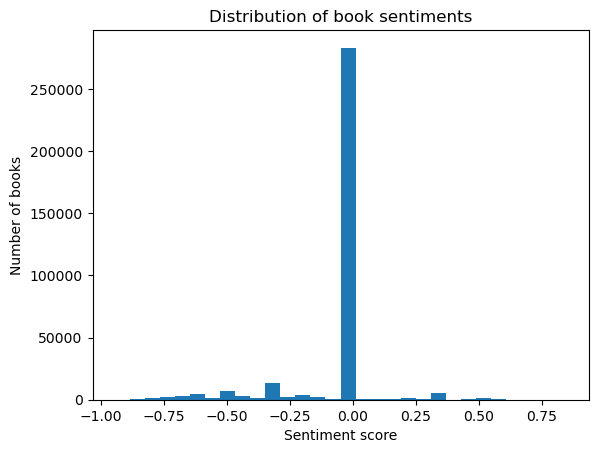

In [89]:
plt.hist(list(sentiment_score_per_book.values()), bins=30)
plt.xlabel('Sentiment score')
plt.ylabel('Number of books')
plt.title('Distribution of book sentiments')
plt.show()